In [17]:
import yfinance as yf
df = yf.download("AAPL", start="2020-01-01", end="2026-05-12")


[*********************100%***********************]  1 of 1 completed


In [18]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [19]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-05-05,283.918427,284.308082,276.245503,276.675100,49311700
2026-05-06,287.245361,287.764872,280.811287,281.660510,58336100
2026-05-07,287.175415,291.861100,285.516939,289.003717,45224300
2026-05-08,293.050018,294.488695,289.733067,289.743067,52692800
2026-05-11,292.679993,293.880005,290.230011,291.980011,42247300


In [20]:
df.shape

(1597, 5)

In [21]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1597 entries, 2020-01-02 to 2026-05-11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1597 non-null   float64
 1   (High, AAPL)    1597 non-null   float64
 2   (Low, AAPL)     1597 non-null   float64
 3   (Open, AAPL)    1597 non-null   float64
 4   (Volume, AAPL)  1597 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.9 KB


In [22]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1597.000000,1597.000000,1597.000000,1597.000000,1.597000e+03
mean,170.118561,171.861094,168.214589,169.961891,8.246288e+07
std,53.303032,53.665839,52.903832,53.268446,5.076540e+07
min,54.163712,55.160709,51.324807,55.059320,1.791060e+07
25%,133.226990,135.352795,131.891520,133.151117,4.931170e+07
50%,167.321671,168.915686,165.802306,167.321670,6.844560e+07
75%,210.435150,212.556737,208.094440,210.116417,9.791850e+07
max,293.050018,294.488695,290.230011,291.980011,4.265100e+08


In [23]:
print(df.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


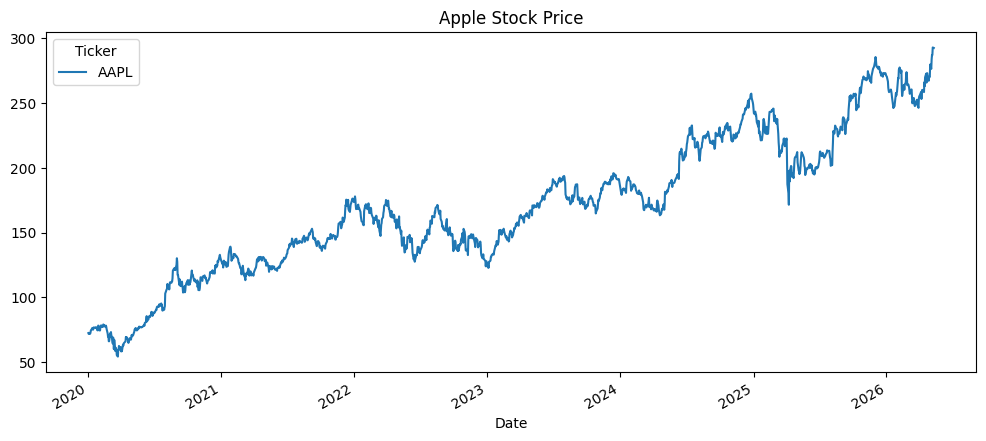

In [24]:
import matplotlib.pyplot as plt
df['Close'].plot(figsize=(12,5), title="Apple Stock Price")
plt.show()

In [25]:
# Fix the multi-level columns issue
df.columns = df.columns.droplevel(1)
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [26]:
# Feature Engineering
df['Return'] = df['Close'].pct_change()
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['Volatility'] = df['Return'].rolling(10).std()
df['Momentum'] = df['Close'] - df['MA_10']
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)

# Drop nulls
df.dropna(inplace=True)

print(df.head())
print(df.shape)

Price           Close       High        Low       Open     Volume    Return  \
Date                                                                          
2020-03-13  67.102928  67.573668  61.063012  63.945374  370732000  0.119808   
2020-03-16  58.470352  62.542825  57.936849  58.407585  322423600 -0.128647   
2020-03-17  61.041286  62.187949  57.550590  59.749776  324056000  0.043970   
2020-03-18  59.546997  60.350871  57.241593  57.881315  300233600 -0.024480   
2020-03-19  59.090759  61.036471  58.566914  59.720823  271857200 -0.007662   

Price           MA_10      MA_50  Volatility  Momentum  Target  
Date                                                            
2020-03-13  68.219663  73.733390    0.074268 -1.116735       0  
2020-03-16  66.853321  73.456119    0.077772 -8.382969       1  
2020-03-17  65.973163  73.244333    0.079945 -4.931877       0  
2020-03-18  64.619613  72.991244    0.077447 -5.072615       0  
2020-03-19  63.457495  72.735823    0.077314 -4.366736  

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Define features and target
features = ['Return', 'MA_10', 'MA_50', 'Volatility', 'Momentum']
X = df[features]
y = df['Target']

# Split — important: shuffle=False for time series data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.4838709677419355

Detailed Report:
              precision    recall  f1-score   support

           0       0.47      0.64      0.54       149
           1       0.50      0.34      0.41       161

    accuracy                           0.48       310
   macro avg       0.49      0.49      0.48       310
weighted avg       0.49      0.48      0.47       310



In [28]:
# Better features
df['MA_10_slope'] = df['MA_10'].pct_change()  
df['MA_50_slope'] = df['MA_50'].pct_change()  
df['Price_vs_MA10'] = df['Close'] / df['MA_10']  
df['Price_vs_MA50'] = df['Close'] / df['MA_50']  
df['Volume_change'] = df['Volume'].pct_change()
df['High_Low_range'] = (df['High'] - df['Low']) / df['Close']

df.dropna(inplace=True)

# Retrain with better features
features = [
    'Return', 'Volatility', 'Momentum',
    'MA_10_slope', 'MA_50_slope',
    'Price_vs_MA10', 'Price_vs_MA50',
    'Volume_change', 'High_Low_range'
]

X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.5225806451612903
              precision    recall  f1-score   support

           0       0.51      0.33      0.40       149
           1       0.53      0.70      0.60       161

    accuracy                           0.52       310
   macro avg       0.52      0.52      0.50       310
weighted avg       0.52      0.52      0.51       310



In [29]:
import joblib
joblib.dump(model, 'stock_model.pkl')
print("Model saved!")

Model saved!


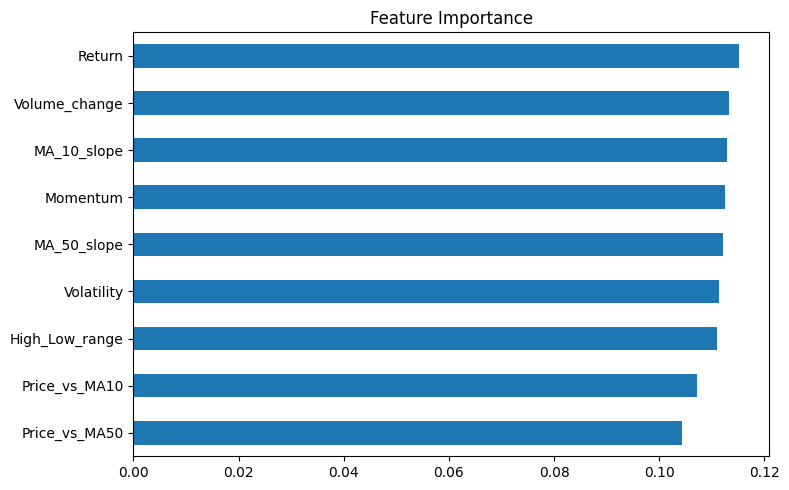

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(8,5), title='Feature Importance')
plt.tight_layout()
plt.show()